1\. **PCA on 3D dataset**

* Generate a dataset with 3 features each with N entries (N being ${\cal O}(1000)$). With $N(\mu,\sigma)$ the normali distribution with mean $\mu$ and $\sigma$  standard deviation, generate the 3 variables $x_{1,2,3}$ such that:
    * $x_1$ is distributed as $N(0,1)$
    * $x_2$ is distributed as $x_1+N(0,3)$
    * $x_3$ is given by $2x_1+x_2$
* Find the eigenvectors and eigenvalues of the covariance matrix of the dataset
* Find the eigenvectors and eigenvalues using SVD. Check that the two procedures yield to same result
* What percent of the total dataset's variability is explained by the principal components? Given how the dataset was constructed, do these make sense? Reduce the dimensionality of the system so that at least 99% of the total variability is retained.
* Redefine the data in the basis yielded by the PCA procedure
* Plot the data points in the original and the new coordiantes as a set of scatter plots. Your final figure should have 2 rows of 3 plots each, where the columns show the (0,1), (0,2) and (1,2) proejctions.


In [1]:
import numpy as np
from scipy import linalg as la
import matplotlib.pyplot as plt

Are both procedures equal? True 

The percent of the total dataset variability for x1, x2 and x3 respectivley, is: 
 93.1363270289962 -3.095876068225685e-15 6.863672971003795 

Number of principal components to retain ≥99% variance: 2


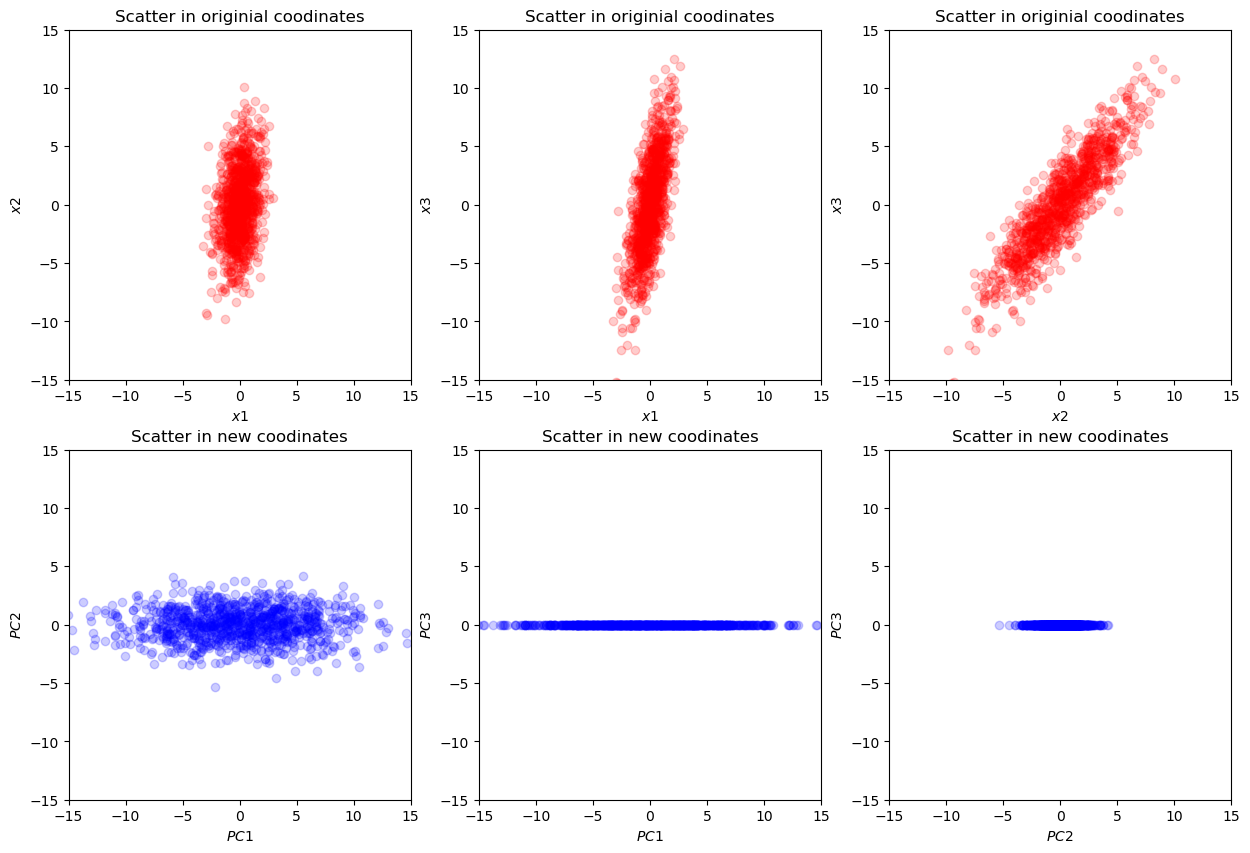

In [2]:
# Dataset with 3 features, each with N(mu,sigma).
mu = 0 
N = 1000
    # x1 as N(0,1)
sigma1 = 1
x1 = np.random.normal(mu, sigma1, N).T
    # x2 as x1 + N(0,3)
sigma2 = 3
noise2 = np.random.normal(mu, sigma2, N)
x2 = x1 + noise2
    # x3 as 2 * x1 + x2
x3 = 2 * x1 + x2

# Eigenvectors and eigenvalues of the covariance matrix of the dataset.
X = np.vstack((x1, x2, x3)) # Remember that " X " rows have to be the variables to apply " .cov(X) ".
l0, V0 = la.eig(np.cov(X))
X_cov = np.real_if_close(np.dot(V0, np.dot(np.diag(l0), V0.T))) # We take only the real part (imaginary appears because of approximations).
# If we want to order the eigenvalues (descending):
   # idx_cov = np.argsort(l_cov)[::-1]       
   # l_cov_sorted = l_cov[idx_cov]
   # V_cov_sorted = V_cov[:, idx_cov]

# Eigenvectors and eigenvalues using SVD.
Xc = X - X.mean(axis=1, keepdims=True) # We need centered data for SVD.
U, spectrum, Vt = la.svd(Xc) # " X " is a 3xN matrix so U will be 3x3 because X = U * spectrum * Vt.
l_svd = spectrum**2 / (N-1) # In this case, the eigenvalues are ordered from largest to smallest.
V_svd = U
X_svd = np.dot(V_svd, np.dot(np.diag(l_svd), V_svd.T))
# Check if the two procedures yield to same result (with an 0.1 aprox. error).
print('Are both procedures equal?', np.allclose(X_cov, X_svd),'\n')

# Total dataset's variability explained by the principal components. 
# Reduced the dimensionality with at least 99% of the total variability retained.
total_var = sum(np.real_if_close(l0))
p_var = 100 * np.real_if_close(l0) / total_var
print('The percent of the total dataset variability for x1, x2 and x3 respectivley, is:','\n',p_var[0],p_var[1],p_var[2],'\n')
cumulative_var = np.cumsum(p_var)  # Cumulative sum in percent.
num_pcs = np.argmax(cumulative_var >= 99) 
print("Number of principal components to retain ≥99% variance:", num_pcs)
# Since the dataset is generated from two independent sources of variability, it is expected that almost all of the total variance 
# is concentrated in two principal components. The first principal component explains around 90% of the variance because it 
# corresponds to a linear combination dominated by the source with the larger variance, N(0,3), while the second principal 
# component captures the remaining variability associated with N(0,1).

# Data in the basis yielded by the PCA procedure.
Xp = np.dot(V_svd.T,Xc).T

# Plot of data points in the original and the new coordiantes as a set of scatter plots. 
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
ax1, ax2, ax3, ax4, ax5, ax6 = axes.flatten()

ax1.scatter(x=x1, y=x2, marker='o', c='r', alpha=0.2)
ax1.set_title('Scatter in originial coodinates')
ax1.set_xlabel('$x1$')
ax1.set_ylabel('$x2$')

ax2.scatter(x=x1, y=x3, marker='o', c='r', alpha=0.2)
ax2.set_title('Scatter in originial coodinates')
ax2.set_xlabel('$x1$')
ax2.set_ylabel('$x3$')

ax3.scatter(x=x2, y=x3, marker='o', c='r', alpha=0.2)
ax3.set_title('Scatter in originial coodinates')
ax3.set_xlabel('$x2$')
ax3.set_ylabel('$x3$')

ax4.scatter(x=Xp[:,0], y=Xp[:,1], marker='o', c='b', alpha=0.2)
ax4.set_title('Scatter in new coodinates')
ax4.set_xlabel('$PC1$')
ax4.set_ylabel('$PC2$')

ax5.scatter(x=Xp[:,0], y=Xp[:,2], marker='o', c='b', alpha=0.2)
ax5.set_title('Scatter in new coodinates')
ax5.set_xlabel('$PC1$')
ax5.set_ylabel('$PC3$')

ax6.scatter(x=Xp[:,1], y=Xp[:,2], marker='o', c='b', alpha=0.2)
ax6.set_title('Scatter in new coodinates')
ax6.set_xlabel('$PC2$')
ax6.set_ylabel('$PC3$')

for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
    ax.set_xlim(-15, 15)   # set x-axis from -20 to 20
    ax.set_ylim(-15, 15)   # set y-axis from -20 to 20

2\. **PCA on a nD dataset**

Start from the dataset you have genereted in the previous exercise and add uncorrelated random noise. Such noise should be represented by other 10 uncorrelated variables normal distributed, with standar deviation much smaller (say, a factor 50) than those used to generate the $x_1$ and $x_2$.

Repeat the PCA procedure and compare the results with what you obtained before

In [3]:
# Addition of uncorrelated random noise to the previous dataset.
num_noise = 10
noise_sigma = sigma1 / 50  # much smaller than original sigmas
noise = np.random.normal(mu, noise_sigma, size=(num_noise, N))  # 10 x N

# PCA procedure and comparation of the results with what you obtained before.
# Using " np.cov() ".
X_nd = np.vstack((X, noise))  # 13 x N
l_cov, V_cov = la.eig(np.cov(X_nd))
# Using " la.svd() " (better because eigenvalues are ordered from highest to lowest).
Xc_nd = X_nd - X_nd.mean(axis=1, keepdims=True)
U_nd, S_nd, Vt_nd = la.svd(Xc_nd)
l_svd_nd = (S_nd**2) / (N-1)
V_svd_nd = U_nd
print(np.real_if_close(l_svd),'\n',np.real_if_close(V_svd),'\n')
print(np.real_if_close(l_svd_nd),'\n',np.real_if_close(V_svd_nd))

[2.69414474e+01 1.98544746e+00 4.38087280e-32] 
 [[-0.10976687  0.5668197  -0.81649658]
 [-0.58444264 -0.70125611 -0.40824829]
 [-0.80397639  0.43238328  0.40824829]] 

[2.69414503e+01 1.98545403e+00 4.57597244e-04 4.42630389e-04
 4.30715196e-04 4.07089092e-04 4.05263001e-04 3.88826107e-04
 3.84735170e-04 3.71792457e-04 3.51678670e-04 3.33774039e-04
 4.28403583e-32] 
 [[-1.09766857e-01  5.66818786e-01 -5.74837368e-04  8.45172974e-07
   2.77016435e-04  6.30479395e-04 -1.56118886e-04 -2.89944256e-04
   4.97782825e-05  2.33976203e-04 -1.00772237e-04  2.31968675e-04
  -8.16496581e-01]
 [-5.84442623e-01 -7.01254802e-01  6.93627688e-04 -2.13218929e-05
  -2.99670150e-04 -9.29172392e-04  2.69792983e-04  2.63983404e-04
  -6.30265053e-05 -2.99383057e-04  2.14442647e-04 -3.73844561e-04
  -4.08248290e-01]
 [-8.03976337e-01  4.32382770e-01 -4.56047048e-04 -1.96315470e-05
   2.54362720e-04  3.31786399e-04 -4.24447885e-05 -3.15905107e-04
   3.65300596e-05  1.68569350e-04  1.28981730e-05  9.00927889e-

3 \. **Looking at an oscillating spring** (optional)

Imagine you have $n$ cameras looking at a spring oscillating along the $x$ axis. Each  camera record the motion of the spring looking at it along a given direction defined by the pair $(\theta_i, \phi_i)$, the angles in spherical coordinates. 

Start from the simulation of the records (say ${\cal O}(1000)$) of the spring's motion along the x axis, assuming a little random noise affects the measurements along the $y$. Rotate such dataset to emulate the records of each camera.

Perform a Principal Component Analysis on the thus obtained dataset, aiming at finding the only one coordinate that really matters.


4\. **PCA on the MAGIC dataset** (optional)

Perform a PCA on the magic04.data dataset

In [4]:
# get the dataset and its description on the proper data directory
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/magic/magic04.data -P ~/data/
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/magic/magic04.names -P ~/data/ 

"wget" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.
"wget" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.
